In [2]:
# General notebook settings
import logging
import warnings

import pypsa

warnings.filterwarnings("error", category=DeprecationWarning)
logging.getLogger("gurobipy").propagate = True
pypsa.options.params.optimize.log_to_console = True

# Piecewise costs and constraints

In this example, we demonstrate how to represent non-linear system relationships as piecewise-linear curves in PyPSA. 
This allows us to describe such relationships as:

- Economies of scale (investment costs per unit capacity reduce as an asset's capacity increases)
- Marginal cost offer curves (marginal cost per unit dispatched energy changes an asset's dispatch increases)
- Part-load efficiencies (efficiency varies when an asset operates below its rated capacity)

Here, we build a model from the [single-node capacity expansion example]() and update the electrolysis component with various piecewise curves. 
Note that the goal here is not necessarily to showcase a realistic scenario, but rather to demonstrate how it is possible to model piecewise costs and constraints in PyPSA.

In [3]:
import matplotlib.pyplot as plt
import numpy as np

In [4]:
n = pypsa.examples.model_energy()

# Add a hydrogen load to ensure electrolysis *must* be dispatched in the solution
n.add("Load", "hydrogen-demand", bus="hydrogen", p_set=n.loads_t.p_set["demand"] / 100)
n.components["Link"].static.loc["electrolysis", "marginal_cost"] = 10

INFO:pypsa.network.io:Retrieving network data from https://github.com/PyPSA/PyPSA/raw/v1.1.2/examples/networks/model-energy/model-energy.nc.
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Model-Energy' has buses, carriers, generators, links, loads, storage_units, stores


## Reference case

Our reference case will be a model in which the rated values for our CCGT are used.

In [5]:
def update_electrolysis(n: pypsa.Network, **new_attrs) -> pypsa.Network:

    n_new = n.copy()

    n_new.add("Link", "electrolysis", **new_attrs, **n.links.loc["electrolysis"].drop(new_attrs.keys()), overwrite=True)
    n_new.sanitize()
    return n_new


n_ref = update_electrolysis(n)
n_ref.optimize()

INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.consistency:Network sanitization complete.
/var/folders/4n/5q9kdtps1334qh_fqx5jl2xw0000gn/T/ipykernel_91094/525777435.py:11: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n_ref.optimize()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: True
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 1078.43it/s]
INFO:linopy.io: Writing time: 0.12s


Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-hi2knk5_ has 64246 rows; 29206 cols; 124144 nonzeros
Coefficient ranges:
  Matrix  [2e-04, 3e+00]
  Cost    [3e+01, 2e+05]
  Bound   [0e+00, 0e+00]
  RHS     [5e+01, 1e+04]
Presolving model
33618 rows, 27784 cols, 92094 nonzeros  0s
Dependent equations search running on 8760 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
30698 rows, 24864 cols, 86254 nonzeros  0s
Presolve reductions: rows 30698(-33548); columns 24864(-4342); nonzeros 86254(-37890) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 5840(1.69582e+07) 0.1s
      13866     2.1404111000e+09 Pr: 7407(3.34319e+10); Du: 0(6.96764e-08) 5.2s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 29206 primals, 64246 duals
Objective: 8.29e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


      21654     8.2865196036e+09 Pr: 0(0); Du: 0(1.83632e-11) 9.7s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-hi2knk5_
Model status        : Optimal
Simplex   iterations: 21654
Objective value     :  8.2865196036e+09
P-D objective error :  4.2006915100e-14
HiGHS run time      :          9.74


('ok', 'optimal')

## Creating piecewise relationships

Let's assume the following relationships:

1. The marginal investment cost of our electrolysis facility decreases until a tipping point where additional capacity faces a *diseconomy*.
   This could be caused by land purchase costs increasing for additional capacity beyond a certain level.
   We will describe this with a sigmoid-like curve:

   $$
   \frac{C_{inv}}{C_{inv}^{max}}\ =\frac{\left(\ (\frac{P_{nom}}{P_{nom}^{max}}-1/2)\sqrt{\left(1-k/4\right)}\right)}{\sqrt{\left(1-k(\frac{P_{nom}}{P_{nom}^{max}}-1/2)^{2}\right)}}+1/2
   $$

   For this example, we will use a scaling factor $k$ of 2.4

2. The electrolysis component in PyPSA represents a collection of real facilities, each with different marginal costs which will be applied in order of merit. 
   We will represent this marginal cost offer curve as:

   $$
   C_m = C_0 + \alpha \cdot \frac{P}{P^{max}} + \beta \cdot (\frac{P}{P^{max}})^3
   $$

   For this example, let's assume $C_0$ = 5, $\alpha$ = 2 €/MWh, $\beta$ = 3€/MW³h

1. The efficiency of electrolysis degrades at part-load.
   Let's assume it follows a square root curve bounded by $\eta$ = 70% at full load and $\eta$ = 40% at 0% load:

   $$
   \eta = (\eta^{max} - \eta^{min}) \cdot \sqrt{\frac{P}{P^{max}}} + \eta^{min}
   $$

We can approximate these non-linear relationships with a series of straight lines or `segments`. 
Here, we will heuristically select points along each curve to derive these segments.

In [6]:
def plot_piecewise_constraints(
    x_max, n_breakpoints, y_ref, y_func, title, xlabel, ylabel, min_x=0
):
    x_continuous = np.linspace(min_x, x_max, 500)
    x_breakpoints = np.linspace(min_x, x_max, n_breakpoints)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(x_continuous, y_func(x_continuous), lw=2, label="Non-linear curve")
    ax.plot(x_breakpoints, y_func(x_breakpoints), "--o", lw=2, label="Piecewise linear")
    ax.plot([min_x, x_max], y_ref, "-.o", lw=2, label="Reference linear")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

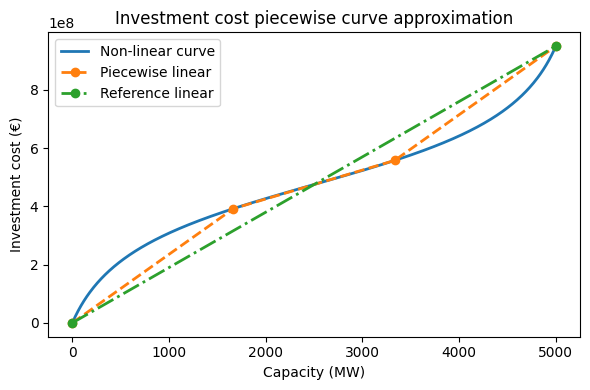

In [7]:
# 1. Investment cost – economy of scale followed by diseconomy of scale
P_max_inv = 5000  # MW
C_max_inv = 190000 * P_max_inv  # €
k = 3


def get_inv_cost_curve(P: np.array):
    p = P / P_max_inv - 0.5
    return C_max_inv * (p * np.sqrt(1 - k / 4) / np.sqrt(1 - k * p**2) + 0.5)


plot_piecewise_constraints(
    P_max_inv,
    4,
    (0, C_max_inv),
    get_inv_cost_curve,
    "Investment cost piecewise curve approximation",
    "Capacity (MW)",
    "Investment cost (€)",
)

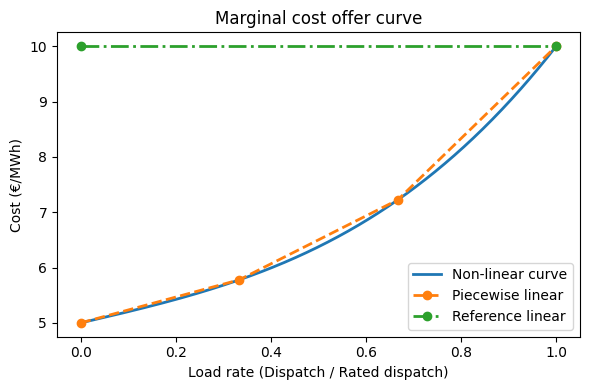

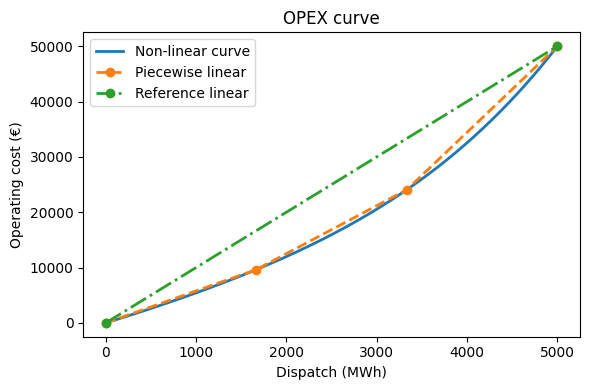

In [8]:
# 2. Marginal cost offer curve
C0_mc = 5  # €/h
alpha_mc = 2  # €/MWh
beta_mc = 3  # €/MW²h
P_max = 5000

def get_marginal_cost_curve(P_frac):
    return C0_mc + alpha_mc * P_frac + beta_mc * P_frac**3

def get_opex_curve(P_out):
    P_frac = P_out / P_max
    marginal_cost = get_marginal_cost_curve(P_frac)
    return marginal_cost * P_out


ref_mc = C0_mc + alpha_mc + beta_mc
plot_piecewise_constraints(
    1,
    4,
    (ref_mc, ref_mc),
    get_marginal_cost_curve,
    "Marginal cost offer curve",
    "Load rate (Dispatch / Rated dispatch)",
    "Cost (€/MWh)",
)
plot_piecewise_constraints(
    5000,
    4,
    (0, ref_mc * P_max),
    get_opex_curve,
    "OPEX curve",
    "Dispatch (MWh)",
    "Operating cost (€)",
)

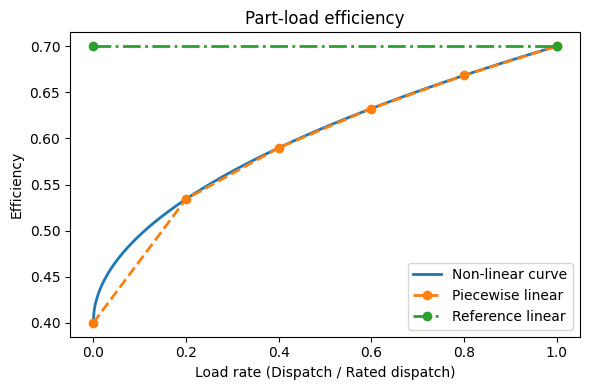

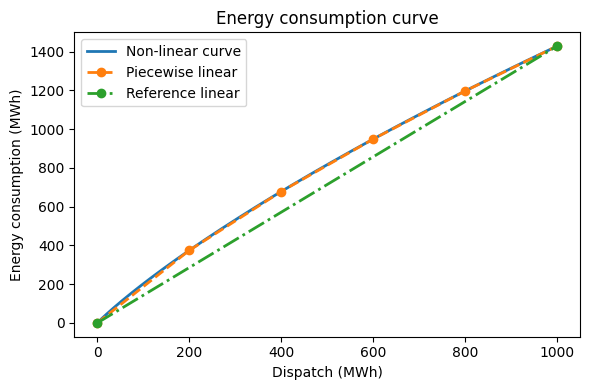

In [9]:
# 3. Part-load efficiency
eta_rated = 0.7  # efficiency at full load
eta_min = 0.4    # efficiency at zero load
P_frac_min = 0   # minimum load fraction (η is finite at zero load)
P_max = 1000

def get_part_load_eff_curve(P_frac):
    return (eta_rated - eta_min) * np.sqrt(P_frac) + eta_min

def get_load_in_curve(P_out):
    eff = get_part_load_eff_curve(P_out / P_max)
    return P_out / eff


plot_piecewise_constraints(
    1,
    6,
    (eta_rated, eta_rated),
    get_part_load_eff_curve,
    "Part-load efficiency",
    "Load rate (Dispatch / Rated dispatch)",
    "Efficiency",
    min_x=P_frac_min,
)


plot_piecewise_constraints(
    P_max,
    6,
    (0, P_max / eta_rated),
    get_load_in_curve,
    "Energy consumption curve",
    "Dispatch (MWh)",
    "Energy consumption (MWh)",
    min_x=P_frac_min,
)

## Piecewise attributes for extendable components

Of the above curves, only (dis)economies of scale can be applied to the case where our electrolysis component is extendable.
The other two relate to the load rate of a component (`p/p_nom`) which is a non-linear relationship of two decision variables when the component is extendable.

Let's see what happens when we add this piecewise constraint:

In [10]:
p_nom_breakpoints = np.array([0, 1000, 2000, 3000, 4000])
capital_costs = get_inv_cost_curve(p_nom_breakpoints)
n_piecewise_capex = update_electrolysis(
    n,
    capital_cost=dict(zip(p_nom_breakpoints, capital_costs)),
)
n_piecewise_capex.optimize(reformulate_sos="auto")

INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.consistency:Network sanitization complete.
/var/folders/4n/5q9kdtps1334qh_fqx5jl2xw0000gn/T/ipykernel_91094/1359902992.py:7: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n_piecewise_capex.optimize(reformulate_sos="auto")
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: True
INFO:linopy.model:Reformulating SOS constraints for solver highs
INFO:linopy.sos_reformulation:Reformulated 1 SOS constraint(s)
INFO:linopy.io:Writing objective.
Writing binary variables.: 100%|██████████| 1/1 [00:00<00:00, 797.55it/s]
INFO:linopy.io: Writing time: 0.12s


Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
MIP linopy-problem-ythg31l4 has 64256 rows; 29217 cols; 124178 nonzeros; 4 integer variables (4 binary)
Coefficient ranges:
  Matrix  [2e-04, 6e+08]
  Cost    [1e+00, 1e+05]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+04]
Presolving model
33628 rows, 27795 cols, 92128 nonzeros  0s
30707 rows, 24874 cols, 86286 nonzeros  0s
Presolve reductions: rows 30707(-33549); columns 24874(-4343); nonzeros 86286(-37892) 

Solving MIP model with:
   30707 rows
   24874 cols (4 binary, 0 integer, 0 implied int., 24870 continuous, 0 domain fixed)
   86286 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 29217 primals, 64256 duals
Objective: 8.22e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


         1       0         1 100.00%   8224941103.397  8224941103.397     0.00%        3      3      1     25054    18.1s

Solving report
  Model             linopy-problem-ythg31l4
  Status            Optimal
  Primal bound      8224941103.4
  Dual bound        8224941103.4
  Gap               0% (tolerance: 0.01%)
  P-D integral      0.0272023696517
  Solution status   feasible
                    8224941103.4 (objective)
                    0 (bound viol.)
                    0 (int. viol.)
                    0 (row viol.)
  Timing            18.07
  Max sub-MIP depth 0
  Nodes             1
  Repair LPs        0
  LP iterations     25054
                    0 (strong br.)
                    3 (separation)
                    681 (heuristics)


('ok', 'optimal')

We can see the results stored in a new component `segments` data table:

In [11]:
display(n_piecewise_capex.c.links.segments.capital_cost)

name      electrolysis              
attribute        p_nom  capital_cost
segment                             
0                    0  0.000000e+00
1                 1000  3.082164e+08
2                 2000  4.267711e+08
3                 3000  5.232289e+08
4                 4000  6.417836e+08

We can see that the capital expenditure in electrolysis capacity sits on our piecewise curve:

Text(0.5, 1.0, 'Electrolysis capital costs (CAPEX)')

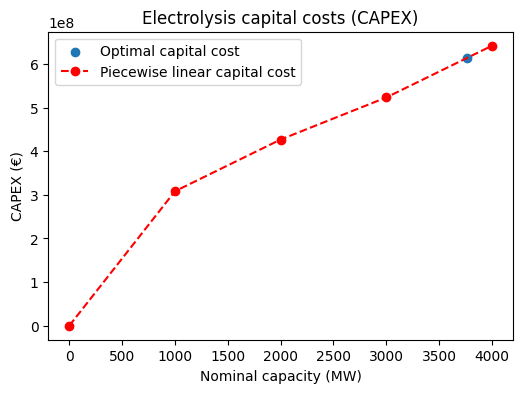

In [12]:
capital_cost_opt = n_piecewise_capex.links.loc["electrolysis", "capital_cost_piecewise_opt"]
p_nom_opt = n_piecewise_capex.links.loc["electrolysis", "p_nom_opt"]
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.scatter(p_nom_opt, capital_cost_opt, label="Optimal capital cost")
ax.plot(p_nom_breakpoints, capital_costs, "--o", color="red", label="Piecewise linear capital cost")
ax.legend()
ax.set_xlabel("Nominal capacity (MW)")
ax.set_ylabel("CAPEX (€)")
ax.set_title("Electrolysis capital costs (CAPEX)")

## Piecewise attributes for non-extendable components

Let's fix the capacity and apply our marginal cost piecewise constraint.
Unlike capital cost, which is defined as capital expenditure at each `p_nom` level, marginal cost is defined per unit dispatch, namely `p_pu`.
This means, our breakpoints exist in the range zero to one.

In [13]:
p_pu_breakpoints = np.array([0, 0.25, 0.5, 0.75, 1.0])
marginal_cost = get_marginal_cost_curve(p_pu_breakpoints)

n_piecewise_opex = update_electrolysis(
    n,
    marginal_cost=dict(zip(p_pu_breakpoints, marginal_cost)),
    p_nom_extendable=False,
    p_nom=n_ref.links.loc["electrolysis", "p_nom_opt"]
)
n_piecewise_opex.optimize()

INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.consistency:Network sanitization complete.
/var/folders/4n/5q9kdtps1334qh_fqx5jl2xw0000gn/T/ipykernel_91094/3556504569.py:10: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n_piecewise_opex.optimize()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: True
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 12/12 [00:00<00:00, 724.15it/s]
INFO:linopy.io: Writing time: 0.13s


Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-22qyij1z has 81765 rows; 32125 cols; 150423 nonzeros
Coefficient ranges:
  Matrix  [2e-04, 2e+01]
  Cost    [3e+00, 1e+05]
  Bound   [0e+00, 0e+00]
  RHS     [5e+01, 2e+04]
Presolving model
42378 rows, 30703 cols, 109614 nonzeros  0s
Dependent equations search running on 8760 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
39458 rows, 27783 cols, 103774 nonzeros  0s
Presolve reductions: rows 39458(-42307); columns 27783(-4342); nonzeros 103774(-46649) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 5840(2.62892e+07) 0.1s
      20273     7.0294556569e+09 Pr: 6139(1.79967e+08) 5.5s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 32125 primals, 81765 duals
Objective: 7.77e+09
Solver model: available
Solver message: Optimal



      28809     7.7718634969e+09 Pr: 0(0); Du: 0(1.23608e-11) 9.9s
      28809     7.7718634969e+09 Pr: 0(0); Du: 0(1.23608e-11) 9.9s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-22qyij1z
Model status        : Optimal
Simplex   iterations: 28809
Objective value     :  7.7718634969e+09
P-D objective error :  7.4300043841e-14
HiGHS run time      :          9.93


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance, Link-marginal_cost_piecewise_lp, Link-marginal_cost_piecewise_lp_domain_lo, Link-marginal_cost_piecewise_lp_domain_hi were not assigned to the network.


('ok', 'optimal')

As with capital cost in our previous example, we can see our marginal cost defined in the segments data table.
This time, however, the values are given per unit, i.e., `€/MWh`.
In the capital cost case, they were given as total cost at each point along the curve (i.e., `€`).

In [14]:
display(n_piecewise_opex.c.links.segments.marginal_cost)

name      electrolysis              
attribute         p_pu marginal_cost
segment                             
0                 0.00      5.000000
1                 0.25      5.546875
2                 0.50      6.375000
3                 0.75      7.765625
4                 1.00     10.000000

We can see that the marginal costs of electrolysis follow our piecewise curve:

Text(0.5, 1.0, 'Per-snapshot electrolysis operating costs (OPEX)')

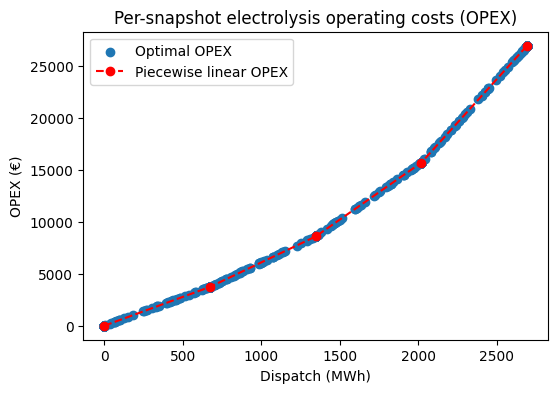

In [15]:
marginal_cost_opt = n_piecewise_opex.links_t.marginal_cost_piecewise["electrolysis"]
p = n_piecewise_opex.links_t.p["electrolysis"]
p_nom_opt = n_piecewise_opex.links.loc["electrolysis", "p_nom"]
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.scatter(p, marginal_cost_opt, label="Optimal OPEX")
ax.plot(p_pu_breakpoints * p_nom_opt, marginal_cost * p_nom_opt * p_pu_breakpoints, "--o", color="red", label="Piecewise linear OPEX")
ax.legend()
ax.set_xlabel("Dispatch (MWh)")
ax.set_ylabel("OPEX (€)")
ax.set_title("Per-snapshot electrolysis operating costs (OPEX)")

Now let's fix the capacity and apply our part-load efficiency piecewise constraint.
As with marginal cost, it requires the capacity to be fixed and for the breakpoints to be defined per unit, i.e., `p_pu`.

Part-load efficiency curves often make the problem much harder to solve, especially compared to piecewise costs.
Therefore, we will only solve the first 200 snapshots of our problem for this example.

In [16]:
p_pu_breakpoints = np.array([0, 0.25, 0.5, 0.75, 1.0])
efficiencies = get_part_load_eff_curve(p_pu_breakpoints)

n_piecewise_efficiency = update_electrolysis(
    n,
    efficiency=dict(zip(p_pu_breakpoints, efficiencies)),
    p_nom_extendable=False,
    p_nom=n_ref.links.loc["electrolysis", "p_nom_opt"],
)
n_piecewise_efficiency.optimize(reformulate_sos=True, snapshots=n.snapshots[:200])

INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.consistency:Network sanitization complete.
/var/folders/4n/5q9kdtps1334qh_fqx5jl2xw0000gn/T/ipykernel_91094/3393154662.py:10: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n_piecewise_efficiency.optimize(reformulate_sos=True, snapshots=n.snapshots[:200])
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: True
INFO:linopy.io: Writing time: 0.12s


Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
MIP linopy-problem-on1nrzkq has 6805 rows; 3805 cols; 14266 nonzeros; 800 integer variables (800 binary)
Coefficient ranges:
  Matrix  [1e-03, 7e+02]
  Cost    [3e+01, 1e+05]
  Bound   [1e+00, 1e+00]
  RHS     [5e+01, 1e+04]
Presolving model
4461 rows, 3466 cols, 11583 nonzeros  0s
3661 rows, 2866 cols, 10183 nonzeros  0s
3661 rows, 2866 cols, 10183 nonzeros  0s
Presolve reductions: rows 3661(-3144); columns 2866(-939); nonzeros 10183(-4083) 

Solving MIP model with:
   3661 rows
   2866 cols (600 binary, 0 integer, 0 implied int., 2266 continuous, 0 domain fixed)
   10183 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => T

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 3805 primals, 6805 duals
Objective: 5.51e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Link-p1_piecewise_inc_link, Link-p1_piecewise_fill, Link-p1_piecewise_inc_order, Link-p1_piecewise_x_link, Link-p1_piecewise_y_link, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


 L       0       0         0   0.00%   5512521049.825  5512674552.533     0.00%      480    147      0      3964     3.9s
         1       0         1 100.00%   5512523762.477  5512674552.533     0.00%      438    147      0      6911     3.9s

Solving report
  Model             linopy-problem-on1nrzkq
  Status            Optimal
  Primal bound      5512674552.53
  Dual bound        5512523762.48
  Gap               0.00274% (tolerance: 0.01%)
  P-D integral      0.00257733757689
  Solution status   feasible
                    5512674552.53 (objective)
                    0 (bound viol.)
                    2.5651008255e-14 (int. viol.)
                    0 (row viol.)
  Timing            3.89
  Max sub-MIP depth 1
  Nodes             1
  Repair LPs        0
  LP iterations     6911
                    0 (strong br.)
                    1061 (separation)
                    4306 (heuristics)


('ok', 'optimal')

We can see that the electrolysis efficiency follow our piecewise curve:

Text(0.5, 1.0, 'Per-snapshot electrolysis operating efficiency')

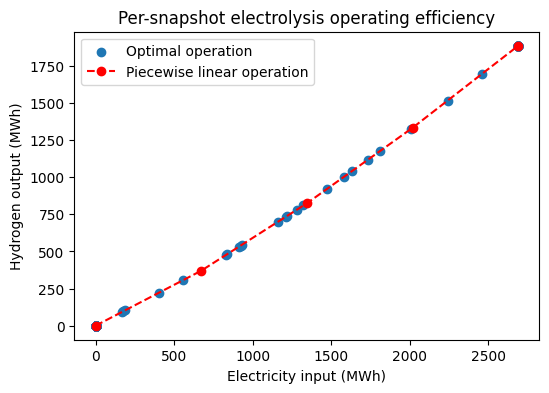

In [17]:
p1_opt = -1 * n_piecewise_efficiency.links_t.p1["electrolysis"]
p = n_piecewise_efficiency.links_t.p["electrolysis"]
p_nom_opt = n_piecewise_efficiency.links.loc["electrolysis", "p_nom"]
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.scatter(p, p1_opt, label="Optimal operation")
ax.plot(p_pu_breakpoints * p_nom_opt, efficiencies * p_nom_opt * p_pu_breakpoints, "--o", color="red", label="Piecewise linear operation")
ax.legend()
ax.set_xlabel("Electricity input (MWh)")
ax.set_ylabel("Hydrogen output (MWh)")
ax.set_title("Per-snapshot electrolysis operating efficiency")